In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, MaxPooling1D, Dropout
from tensorflow.keras.optimizers import Adam
from keras import regularizers

from sklearn.utils import shuffle
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

import sys
sys.path.append("..")

from Src.data_modules import *


# Data Loading

## Train

In [70]:
window_size = 500

X = np.empty((0, 5, 500))
y = np.empty((5, 0))

for s in range(4):
    train_data, train_target = load_train_data(set=s)
    segmented_data = segment_signals(train_data, window_size)

    X = np.concatenate([X, segmented_data], axis=0)
    y = np.concatenate([y, train_target], axis=1)

In [71]:
# Important filtering
X_filtered = butter_bandpass_filter(X,0.1,50,250,4)

In [72]:
# Reshaper pour normaliser chaque série temporelle (500 points) indépendamment pour chaque échantillon et canal
X_reshaped = X_filtered.reshape(-1, 500)

# Initialiser StandardScaler
scaler = StandardScaler()

# Appliquer la normalisation sur chaque série temporelle
X_normalized = scaler.fit_transform(X_reshaped)

# Remodeler les données normalisées pour retrouver la forme d'origine
X_normalized = X_normalized.reshape(X_filtered.shape[0], 5, 500)

In [22]:
# 1. Charger et prétraiter les données
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y.T, test_size=0.2, random_state=42)

X_train = np.transpose(X_train, (0, 2, 1))
X_test = np.transpose(X_test, (0, 2, 1))

In [73]:
# Mélanger les données X et les labels y
X_normalized, y = shuffle(X_normalized, y.T, random_state=42)
X_normalized = np.transpose(X_normalized, (0, 2, 1))

## Test

In [74]:
window_size = 500

X_test = np.empty((0, 5, 500))

for s in range(2):
    test_data = load_test_data(set=s)
    segmented_data = segment_signals(test_data, window_size)

    X_test = np.concatenate([X_test, segmented_data], axis=0)

In [75]:
# Important filtering
X_test_filtered = butter_bandpass_filter(X_test,0.1,50,250,4)

In [76]:
# Reshaper pour normaliser chaque série temporelle (500 points) indépendamment pour chaque échantillon et canal
X_test_reshaped = X_test_filtered.reshape(-1, 500)

# Initialiser StandardScaler
scaler = StandardScaler()

# Appliquer la normalisation sur chaque série temporelle
X_test_normalized = scaler.fit_transform(X_test_reshaped)

# Remodeler les données normalisées pour retrouver la forme d'origine
X_test_normalized = X_test_normalized.reshape(X_test_filtered.shape[0], 5, 500)

In [77]:
X_test_normalized = np.transpose(X_test_normalized, (0, 2, 1))

# CNN

In [93]:
input_shape = (500, 5)
l2 = 0.01

model = Sequential([
    # Couche 1 : 1D Convolution
    Conv1D(filters=15, kernel_size=20, strides=1, activation='relu', input_shape=input_shape, kernel_regularizer=regularizers.l2(l2=l2)),
    MaxPooling1D(pool_size=2, strides=2),

    # Couche 2 : 1D Convolution
    Conv1D(filters=10, kernel_size=10, strides=1, activation='relu', kernel_regularizer=regularizers.l2(l2=l2)),
    MaxPooling1D(pool_size=2, strides=2),

    # Couche 3 : 1D Convolution
    Conv1D(filters=10, kernel_size=10, strides=1, activation='relu', kernel_regularizer=regularizers.l2(l2=l2)),
    MaxPooling1D(pool_size=2, strides=2),

    # Couche 4 : 1D Convolution
    Conv1D(filters=5, kernel_size=5, strides=1, activation='relu', kernel_regularizer=regularizers.l2(l2=l2)),
    MaxPooling1D(pool_size=2, strides=2),

    # # Couche 5 : 1D Convolution
    # Conv1D(filters=15, kernel_size=5, strides=1, activation='relu', kernel_regularizer=regularizers.l2(l2=l2)),
    # MaxPooling1D(pool_size=2, strides=2),

    # Couche Fully Connected
    Flatten(),
    Dense(20, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='relu'),
    Dropout(0.5),

    # Couche de sortie
    Dense(5, activation='sigmoid')  # Deux classes en sortie
])

# Définir un learning rate spécifique
learning_rate = 0.0001  # Exemple de learning rate

# Initialiser l'optimiseur Adam avec ce taux d'apprentissage
optimizer = Adam(learning_rate=learning_rate)

# Compilation du modèle
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 481, 15)        │         1,515 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 240, 15)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 231, 10)        │         1,510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 115, 10)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 106, 10)        │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 53, 10)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 49, 5)          │           255 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ (None, 24, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 20)             │         2,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,975 (27.25 KB)

 Trainable params: 6,975 (27.25 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
history = model.fit(X_normalized, y, epochs=50, batch_size=64, validation_split=0.2)

Epoch 1/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4095 - loss: 0.9898 - val_accuracy: 0.2941 - val_loss: 0.8038
Epoch 2/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4018 - loss: 0.7943 - val_accuracy: 0.2933 - val_loss: 0.6858
Epoch 3/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3958 - loss: 0.6998 - val_accuracy: 0.2928 - val_loss: 0.6316
Epoch 4/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3104 - loss: 0.6431 - val_accuracy: 0.2931 - val_loss: 0.5771
Epoch 5/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3039 - loss: 0.5980 - val_accuracy: 0.2317 - val_loss: 0.5144
Epoch 6/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2919 - loss: 0.5454 - val_accuracy: 0.2317 - val_loss: 0.4501
Epoch 7/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2905 - loss: 0.5037 - val_accuracy: 0.2317 - val_loss: 0.4193
Epoch 8/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2784 - loss: 0.4758 - val_accuracy: 0.

In [406]:
# Prédictions sur l'ensemble de test
y_pred = (model.predict(X_test) > 0.5)  # Pour une classification binaire

y_pred = y_pred.flatten().tolist()
try:
    y_test = y_test.flatten().tolist()
except AttributeError:
    pass

# Évaluation du modèle
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)

print(f"Score Kappa : {kappa_score}")

328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8866392894661446

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.84      0.85     20730
         1.0       0.90      0.92      0.91     31625

    accuracy                           0.89     52355
   macro avg       0.88      0.88      0.88     52355
weighted avg       0.89      0.89      0.89     52355

Score Kappa : 0.7617151277272813


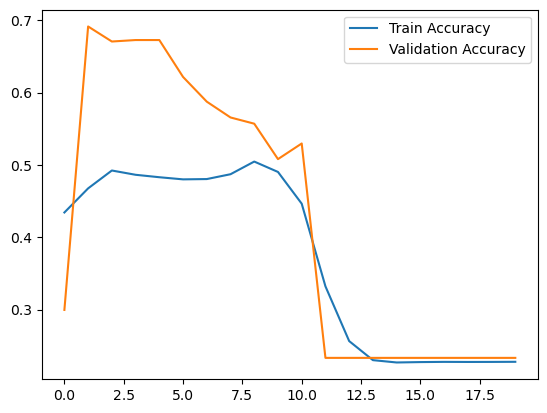

In [407]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Submission

In [91]:
def format_array_to_target_format(array, record_number):

    formatted_target = []
    for i in range(array.shape[0]):
        channel_encoding = (i + 1) * 100000
        record_number_encoding = record_number * 1000000
        for j in range(array.shape[1]):
            formatted_target.append(
                {
                    "identifier": record_number_encoding + channel_encoding + j,
                    "target": array[i, j],
                }
            )
    return formatted_target

In [95]:
results = []

# Set 4
X_test_4 = X_test_normalized[:13204]
preds = (model.predict(X_test_4) > 0.5)
# sublists = [preds[i:i + 13204] for i in range(0, len(preds), 13204)]

formatted_preds = format_array_to_target_format(preds.T, 4)

results.extend(formatted_preds)

# Set 5
X_test_5 = X_test_normalized[13204:]
preds = (model.predict(X_test_5) > 0.5)
# sublists = [preds[i:i + 9319] for i in range(0, len(preds), 9319)]

formatted_preds = format_array_to_target_format(preds.T, 5)

results.extend(formatted_preds)

df = pd.DataFrame(results)


df['target'] = df['target'].apply(lambda x: 1 if x == True else (0 if x == False else x))

df.to_csv("../Results/submission_cnn_raw.csv",index = False)

413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
